# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 3 - Obtaining time series data with GEE and geemap

#### Basic concepts

***ImageCollection***

Most datasets in Earth Engine come as an ImageCollection. An ImageCollection is a dataset consisting of images taken at different times and locations - usually from the same satellite or data provider. You can load a collection by searching the Earth Engine Data Catalog for its ImageCollection ID. Search for the Sentinel-2 Level 1C dataset and you will find its ID COPERNICUS/S2_SR


The collection contains all the images ever collected by the sensor. Entire collections are not very useful. Most applications require a subset of the images. We use filters to select the appropriate images. There are many types of filter functions, see the ee.Filter... module to see all the available filters. Select a filter and run the filter() function with the filter parameters.

We will learn about 3 main types of filtering techniques

- Filter by metadata: You can apply a filter on the image metadata using filters like ee.Filter.eq(), ee.Filter.lt() etc. You can filter by PATH/LINE values, orbit number, cloud cover etc.
- Filter by date: You can select images within a given date range using filters like ee.Filter.date().
- Filter by location: You can select the subset of images with a bounding box, location or geometry using ee.Filter.bounds(). You can also use the drawing tools to draw geometry for filtering.

***Creating mosaics and compositions from ImageCollections***

The default order of the collection is by date. Therefore, when you display the collection, it implicitly creates a mosaic with the most recent pixels on top. You can call .mosaic() on an ImageCollection to create a mosaic image from the pixels at the top.

We can also create a composite image by applying selection criteria to each pixel from all the pixels in the stack. We can use the median() function to create a composite where each pixel value is the median of all the pixels in the stack.

***Geometry***

Earth Engine handles vector data with the Geometry type. The GeoJSON specification describes in detail the geometry types supported by Earth Engine, including Point (a list of coordinates in some projection), LineString (a list of points), LinearRing (a closed LineString), and Polygon (a list of LinearRings where the first is a shell and subsequent rings are holes). Earth Engine also supports MultiPoint, MultiLineString, and MultiPolygon. The GeoJSON GeometryCollection is also supported, although it is named MultiGeometry in Earth Engine.

***FeaturesCollection***

Feature collections are similar to image collections - but they contain features, not images. They are equivalent to Vector Layers in a GIS. We can load, filter, and display feature collections using similar techniques we have learned so far.

To create a feature, provide the constructor with a geometry and (optionally) a dictionary of other properties.

### Import API and get credentials

The Earth Engine API is installed by default in Google Colaboratory, so it only requires import and authentication. These steps must be completed for each new Colab session, if you restart the Colab kernel, or if the Colab virtual machine is recycled due to inactivity.

#### Import the API

Run the following cell to import the API into your session.

In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap

#### Authenticate and initialize

Run the `ee.Authenticate` function to authenticate your access to the Earth Engine servers and `ee.Initialize` to initialize it. When you run the following cell, you will be prompted to grant Earth Engine access to your Google account. Follow the instructions printed in the cell.

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

## Getting Temperature Information

Let's select a coordinate to get information:

In [ ]:
coordinates = np.array([ 23.5544698, 40.025684])
x = float(coordinates[0])
y = float(coordinates[1])

Let's then get temperature data between 2000 and 2010:

In [ ]:
scale = 11132
date_start = '2000-01-01'
date_end = '2010-01-01'

In [ ]:
variables=['mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature']

In [ ]:
location_point = ee.Geometry.Point(x, y)
gre= ee.ImageCollection("ECMWF/ERA5/MONTHLY").select(variables).filter(ee.Filter.date(date_start, date_end))

We convert it into a dataframe:

In [ ]:
data= gre.getRegion(location_point, scale).getInfo()
data=pd.DataFrame(data,columns=data[0])
data = data.drop(0, axis=0)

In [ ]:
data['mean_2m_air_temperature']=data['mean_2m_air_temperature'].astype('float')
data['mean_2m_air_temperature']=data['mean_2m_air_temperature'].apply(lambda x: x-273)
data['minimum_2m_air_temperature']=data['minimum_2m_air_temperature'].astype('float')
data['minimum_2m_air_temperature']=data['minimum_2m_air_temperature'].apply(lambda x: x-273)
data['maximum_2m_air_temperature']=data['maximum_2m_air_temperature'].astype('float')
data['maximum_2m_air_temperature']=data['maximum_2m_air_temperature'].apply(lambda x: x-273)
data['date'] = pd.to_datetime(data['id'], format='%Y%m')
data.set_index("date", inplace=True)
data.head()

,id,longitude,latitude,time,mean_2m_air_temperature,minimum_2m_air_temperature,maximum_2m_air_temperature
date,,,,,,,
2000-01-01,200001,23.550108,40.050183,946684800000,4.550476,-3.027618,14.172150
2000-02-01,200002,23.550108,40.050183,949363200000,7.940460,1.087219,16.480469
2000-03-01,200003,23.550108,40.050183,951868800000,9.482269,1.436859,18.828949
2000-04-01,200004,23.550108,40.050183,954547200000,15.215698,7.144684,22.544739
2000-05-01,200005,23.550108,40.050183,957139200000,19.333221,9.060516,27.031372


We can present it graphically with matplotlib:

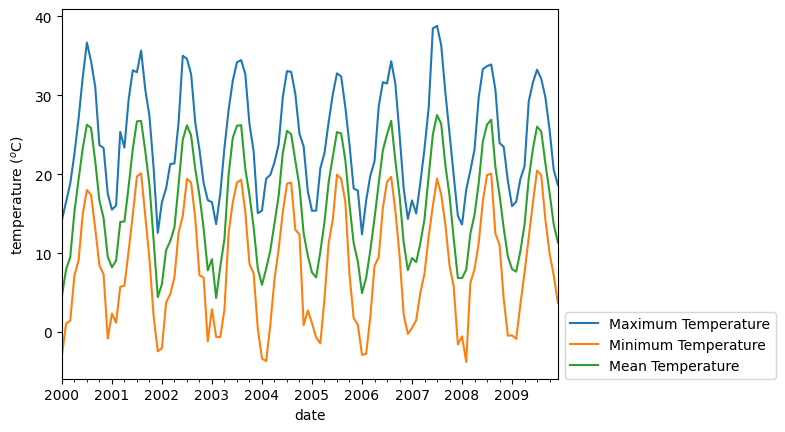

In [ ]:
import matplotlib.pyplot as plt

data.maximum_2m_air_temperature.plot(label='Maximum Temperature')
data.minimum_2m_air_temperature.plot(label='Minimum Temperature')
data.mean_2m_air_temperature.plot(label='Mean Temperature')
plt.ylabel('temperature ($^o$C)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.2))

# Time series by points

Let's use GEE to obtain time series from geometries we have in a .SHP

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import geemap
import pandas as pd
from datetime import datetime as dt
import datetime

We will use this points file:

Download link: https://drive.google.com/drive/folders/1Vn4w8WqHgHta7rwJ5gD_WRARo7b1SLAv?usp=sharing

In [ ]:
path_cana = '/content/drive/MyDrive/Datasets_TS/Pontos_LST/Pontos_cana.shp'

In [ ]:
gdf_cana = gpd.read_file(path_cana)

We will create a column with the class name and convert it to a feature collection:

In [ ]:
gdf_cana['classe'] = 'cana'

In [ ]:
fc = geemap.geopandas_to_ee(gdf_cana)

We will use Modis data for LST from a start and end date:

In [ ]:
lst = ee.ImageCollection('MODIS/061/MOD11A1')

In [ ]:
i_date = '2022-01-01'

f_date = '2023-01-01'

band = lst.select('LST_Day_1km').filterDate(i_date, f_date)

scale = 1000

In [ ]:
lst_full = band.getRegion(fc, scale).getInfo()

With the extracted data we can create a dataframe with this information:

In [ ]:
df = pd.DataFrame(lst_full)
headers = df.iloc[0]
df = pd.DataFrame(df.values[1:], columns=headers)

In [ ]:
df

,id,longitude,latitude,time,LST_Day_1km
0,2022_01_01,-50.462861,-21.330496,1640995200000,None
1,2022_01_02,-50.462861,-21.330496,1641081600000,None
2,2022_01_03,-50.462861,-21.330496,1641168000000,None
3,2022_01_04,-50.462861,-21.330496,1641254400000,None
4,2022_01_05,-50.462861,-21.330496,1641340800000,None
...,...,...,...,...,...
8467,2022_12_27,-50.480827,-21.249648,1672099200000,None
8468,2022_12_28,-50.480827,-21.249648,1672185600000,None
8469,2022_12_29,-50.480827,-21.249648,1672272000000,None
8470,2022_12_30,-50.480827,-21.249648,1672358400000,None


In [ ]:
df = df[['longitude', 'latitude', 'time', "LST_Day_1km" ]].dropna()

In [ ]:
df[ "LST_Day_1km"] = pd.to_numeric(df[ "LST_Day_1km"], errors='coerce')
df['datetime'] = pd.to_datetime(df['time'], unit='ms')
df.drop('time', axis=1, inplace=True)

In [ ]:
df

,longitude,latitude,LST_Day_1km,datetime
7,-50.462861,-21.330496,15327,2022-01-08
14,-50.462861,-21.330496,15554,2022-01-15
20,-50.462861,-21.330496,15449,2022-01-21
21,-50.462861,-21.330496,15382,2022-01-22
22,-50.462861,-21.330496,15396,2022-01-23
...,...,...,...,...
8457,-50.480827,-21.249648,15433,2022-12-17
8461,-50.480827,-21.249648,15220,2022-12-21
8462,-50.480827,-21.249648,15264,2022-12-22
8463,-50.480827,-21.249648,15148,2022-12-23


Let's convert the temperature from Kelvin to Celsius

In [ ]:
def kelvin_to_celcius(t_kelvin):
    t_celsius =  t_kelvin*0.02 - 273.15
    return t_celsius
df['LST_Day_1km'] = df['LST_Day_1km'].apply(kelvin_to_celcius)
df.head()

,longitude,latitude,LST_Day_1km,datetime
7,-50.462861,-21.330496,33.39,2022-01-08
14,-50.462861,-21.330496,37.93,2022-01-15
20,-50.462861,-21.330496,35.83,2022-01-21
21,-50.462861,-21.330496,34.49,2022-01-22
22,-50.462861,-21.330496,34.77,2022-01-23


In [ ]:
df['unique_id'] = (df.groupby(['longitude', 'latitude'], sort=False).ngroup())

In [ ]:
df

,longitude,latitude,LST_Day_1km,datetime,unique_id
7,-50.462861,-21.330496,33.39,2022-01-08,0
14,-50.462861,-21.330496,37.93,2022-01-15,0
20,-50.462861,-21.330496,35.83,2022-01-21,0
21,-50.462861,-21.330496,34.49,2022-01-22,0
22,-50.462861,-21.330496,34.77,2022-01-23,0
...,...,...,...,...,...
8457,-50.480827,-21.249648,35.51,2022-12-17,23
8461,-50.480827,-21.249648,31.25,2022-12-21,23
8462,-50.480827,-21.249648,32.13,2022-12-22,23
8463,-50.480827,-21.249648,29.81,2022-12-23,23


So we can present this information with seaborn:

In [ ]:
import seaborn as sns
sns.set_theme(style="darkgrid")

In [ ]:
df_pt1 = df[df['unique_id'] == 0]

<Axes: xlabel='datetime', ylabel='LST_Day_1km'>

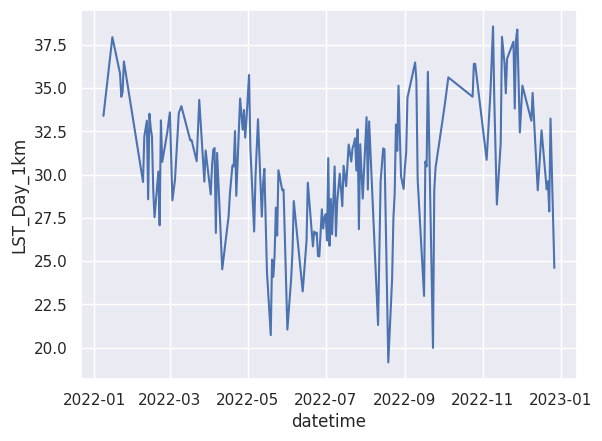

In [ ]:
sns.lineplot(x="datetime", y="LST_Day_1km",
             data=df_pt1)

In [ ]:
df_pts = df[df['unique_id'].isin([0,1,2,3,4,5,6])]

<Axes: xlabel='datetime', ylabel='LST_Day_1km'>

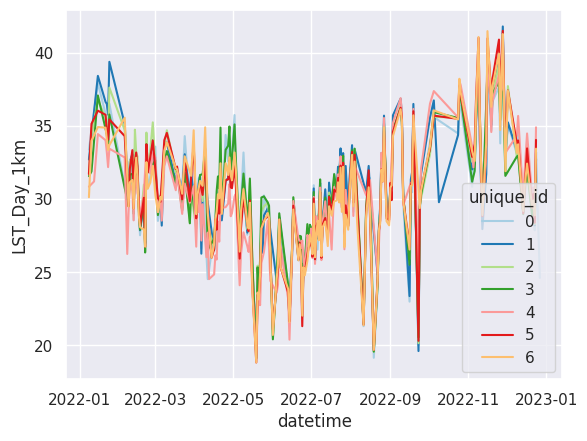

In [ ]:
sns.lineplot(x="datetime", y="LST_Day_1km",
             hue="unique_id", palette="Paired",
             data=df_pts)

In [ ]:
df_pts.to_csv('LST_cana.csv')

# NDVI time series

We will use these polygons to extract information from NDVI time series:

Link to the dataset: https://drive.google.com/drive/folders/1_zwxcE3YM6R4NaXfvoMVCKQaOzA6I_kR?usp=sharing

In [ ]:
path_aoi_soja = '/content/drive/MyDrive/Datasets_TS/AOI_soja/AOI_SOJA.shp'

In [ ]:
gdf_soja = gpd.read_file(path_aoi_soja)

In [ ]:
fc = geemap.geopandas_to_ee(gdf_soja)

In [ ]:
Map = geemap.Map()
Map.add_basemap('HYBRID')
Map.addLayer(fc, {}, 'AOI')
Map.centerObject(fc)
Map

Let's create an image collection of sentinel 2:

In [ ]:
S2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 1)).filterDate('2017-01-01','2024-01-01').filterBounds(fc)

In [ ]:
print('Total number of images :', S2_coll.size().getInfo())

Total number of images : 143


We can view the id of each image in the imageColletion

In [ ]:
S2_coll.aggregate_array('system:id').getInfo()

['COPERNICUS/S2_SR_HARMONIZED/20190509T135119_20190509T135703_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190519T135119_20190519T135613_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190519T135119_20190519T135613_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190608T135119_20190608T135257_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190623T135121_20190623T135116_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190623T135121_20190623T135116_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190628T135119_20190628T135525_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190628T135119_20190628T135525_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190708T135119_20190708T135215_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190718T135119_20190718T135512_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190718T135119_20190718T135512_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190723T135121_20190723T135117_T21KYB',
 'COPERNICUS/S2_SR_HARMONIZED/20190723T135121_20190723T135117_T21KZB',
 'COPERNICUS/S2_SR_HARMONIZED/20190728T135119_20190728T135120_T21KYB',
 'COPE

And also the day and time in timestamp format:

In [ ]:
S2_coll.aggregate_array("system:time_start").getInfo()

[1557410238000,
 1558274239000,
 1558274235000,
 1560002238000,
 1561298234000,
 1561298231000,
 1561730239025,
 1561730235447,
 1562594235000,
 1563458239281,
 1563458235704,
 1563890235624,
 1563890232044,
 1564322238762,
 1564322235185,
 1565186237882,
 1565186234306,
 1567778232751,
 1567778229180,
 1568642230191,
 1568642226618,
 1569938232332,
 1577282225660,
 1577282222086,
 1586786226579,
 1588082233117,
 1588082229536,
 1588514227446,
 1588514223873,
 1590674236655,
 1590674233073,
 1591538236883,
 1591538233299,
 1591970232925,
 1591970229348,
 1592402236609,
 1592402233028,
 1593698232813,
 1593698229238,
 1594130234886,
 1594130231307,
 1594994235458,
 1594994231880,
 1595426232542,
 1595426228972,
 1595858236213,
 1595858232633,
 1596290229915,
 1596722236553,
 1596722232972,
 1598450232293,
 1598882233808,
 1598882230235,
 1601042235896,
 1601042232314,
 1601474233729,
 1617026225500,
 1618322221358,
 1619186226560,
 1620050228710,
 1620050225130,
 1621346230152,
 1621346

We can convert:


In [ ]:
collectionviz = S2_coll.map(
    lambda img: img.set(
        {"DATE": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")}
    )
)

In [ ]:
collectionviz.aggregate_array("DATE").getInfo()

['2019-05-09',
 '2019-05-19',
 '2019-05-19',
 '2019-06-08',
 '2019-06-23',
 '2019-06-23',
 '2019-06-28',
 '2019-06-28',
 '2019-07-08',
 '2019-07-18',
 '2019-07-18',
 '2019-07-23',
 '2019-07-23',
 '2019-07-28',
 '2019-07-28',
 '2019-08-07',
 '2019-08-07',
 '2019-09-06',
 '2019-09-06',
 '2019-09-16',
 '2019-09-16',
 '2019-10-01',
 '2019-12-25',
 '2019-12-25',
 '2020-04-13',
 '2020-04-28',
 '2020-04-28',
 '2020-05-03',
 '2020-05-03',
 '2020-05-28',
 '2020-05-28',
 '2020-06-07',
 '2020-06-07',
 '2020-06-12',
 '2020-06-12',
 '2020-06-17',
 '2020-06-17',
 '2020-07-02',
 '2020-07-02',
 '2020-07-07',
 '2020-07-07',
 '2020-07-17',
 '2020-07-17',
 '2020-07-22',
 '2020-07-22',
 '2020-07-27',
 '2020-07-27',
 '2020-08-01',
 '2020-08-06',
 '2020-08-06',
 '2020-08-26',
 '2020-08-31',
 '2020-08-31',
 '2020-09-25',
 '2020-09-25',
 '2020-09-30',
 '2021-03-29',
 '2021-04-13',
 '2021-04-23',
 '2021-05-03',
 '2021-05-03',
 '2021-05-18',
 '2021-05-18',
 '2021-06-17',
 '2021-06-17',
 '2021-07-02',
 '2021-07-

Each image has its own information:

In [ ]:
image = collectionviz.first()
geemap.image_props(image).getInfo()

{'AOT_RETRIEVAL_ACCURACY': 0,
 'CLOUDY_PIXEL_PERCENTAGE': 0.23051,
 'CLOUD_COVERAGE_ASSESSMENT': 0.23051,
 'CLOUD_SHADOW_PERCENTAGE': 0.208138,
 'DARK_FEATURES_PERCENTAGE': 0.217534,
 'DATASTRIP_ID': 'S2B_OPER_MSI_L2A_DS_SGS__20190509T174916_S20190509T135703_N02.12',
 'DATATAKE_IDENTIFIER': 'GS2B_20190509T135119_011347_N02.12',
 'DATATAKE_TYPE': 'INS-NOBS',
 'DATE': '2019-05-09',
 'DEGRADED_MSI_DATA_PERCENTAGE': 0,
 'FORMAT_CORRECTNESS': 'PASSED',
 'GENERAL_QUALITY': 'PASSED',
 'GENERATION_TIME': 1557424156000,
 'GEOMETRIC_QUALITY': 'PASSED',
 'GRANULE_ID': 'L2A_T21KYB_A011347_20190509T135703',
 'HIGH_PROBA_CLOUDS_PERCENTAGE': 0.142607,
 'IMAGE_DATE': '2019-05-09',
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B1': 130.518923852,
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B10': 133.297764132,
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B11': 131.750556018,
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B12': 130.760680595,
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B2': 137.059218344,
 'MEAN_INCIDENCE_AZIMUTH_ANGLE_B3': 134.440312586,
 'MEAN_INCIDENCE_

We created a function to calculate the NDVI and to obtain the average NDVI for each region:

In [ ]:
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

S2_ndvi = S2_coll.map(addNDVI)

In [ ]:
def meanNDVI(image):
    image = ee.Image(image)
    meanDict = image.reduceRegion(reducer = ee.Reducer.mean().setOutputs(['NDVI']),
        geometry = fc,
        scale = image.projection().nominalScale().getInfo(),
                                    maxPixels = 100000,
                                    bestEffort = True);
    return meanDict.get('NDVI').getInfo()

Then we apply it to the ImageCollection and convert it to a dataframe:

In [ ]:
listOfImages_ndvi = S2_ndvi.select('NDVI').toList(S2_ndvi.size())

ndvi_coll = []

for i in range(listOfImages_ndvi.length().getInfo()):
    image = ee.Image(listOfImages_ndvi.get(i-1))
    temp_ndvi = meanNDVI(image)
    ndvi_coll.append(temp_ndvi)

In [ ]:
dates = np.array(S2_ndvi.aggregate_array("system:time_start").getInfo())
day = [datetime.datetime.fromtimestamp(i/1000).strftime('%Y-%m-%d') for i in (dates)]

In [ ]:
ndvi_df = pd.DataFrame(ndvi_coll, index = day, columns = ['ndvi'])
ndvi_df.index = pd.to_datetime(ndvi_df.index)
ndvi_df.sort_index(ascending = True, inplace = True)

ndvi_df.head(5)

,ndvi
2019-05-09,0.165736
2019-05-19,0.807025
2019-05-19,0.783828
2019-06-08,0.807190
2019-06-23,0.596796


We can present the data:

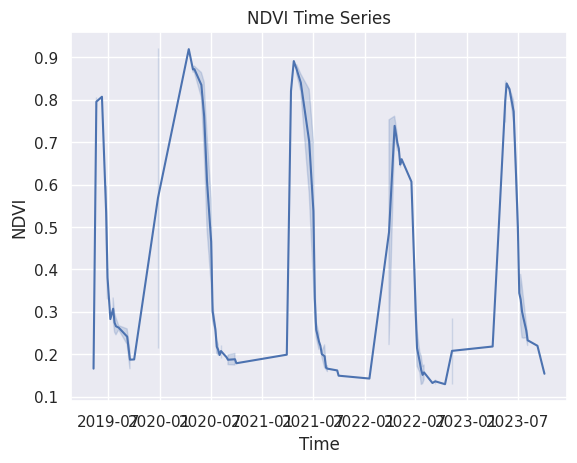

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the time series plot
sns.lineplot(data=ndvi_df, x=ndvi_df.index, y='ndvi')

# Set the title and axis labels
plt.title('NDVI Time Series')
plt.xlabel('Time')
plt.ylabel('NDVI')

# Display the plot
plt.show()


In [ ]:
ndvi_df = ndvi_df.groupby(ndvi_df.index).mean()

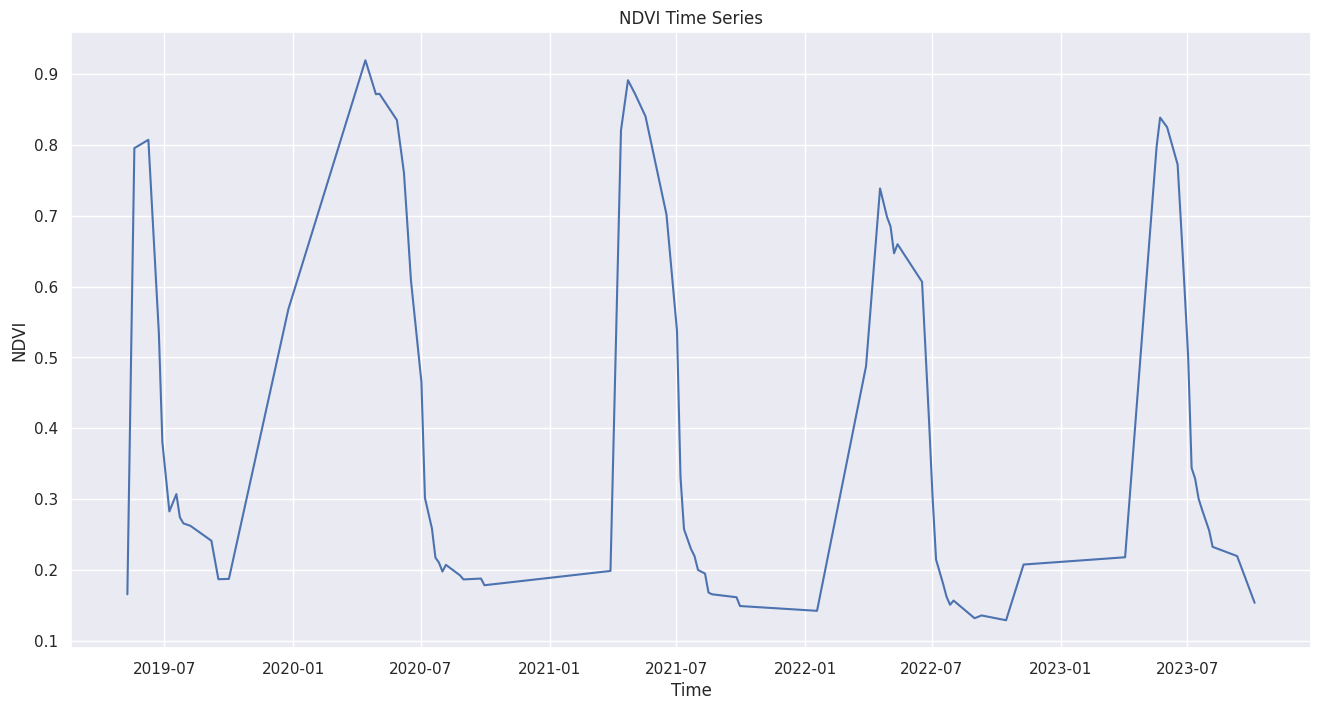

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.set_theme(style="darkgrid")
sns.lineplot(x=ndvi_df.index, y='ndvi', data=ndvi_df)
plt.title('NDVI Time Series')
plt.xlabel('Time')
plt.ylabel('NDVI')
plt.show()

In [ ]:
ndvi_df.to_csv('ndvi_soja.csv')

# Obtaining Time Series from Multiple Spectral Indices

Using the same area, we will obtain time series with different spectral indices:

Link to Dataset: https://drive.google.com/drive/folders/1B2O_kfc_Ntfu2eeNVFBHdPPhH8iI_VDy?usp=sharing

In [ ]:
path_aoi_cana = '/content/drive/MyDrive/Datasets_TS/AOI_cana/cana_lotes.shp'

In [ ]:
gdf_cana = gpd.read_file(path_aoi_cana)

In [ ]:
gdf_cana

,index,geometry
0,0,"POLYGON ((-47.93468 -21.13461, -47.9334 -21.13..."
1,1,"POLYGON ((-47.93154 -21.13705, -47.92954 -21.1..."
2,2,"POLYGON ((-47.9231 -21.13705, -47.92215 -21.13..."
3,3,"POLYGON ((-47.93712 -21.13007, -47.93579 -21.1..."
4,4,"POLYGON ((-47.94116 -21.12812, -47.94111 -21.1..."
5,5,"POLYGON ((-47.92352 -21.14178, -47.92319 -21.1..."


In [ ]:
gdf_cana.reset_index(inplace=True)
gdf_cana.drop(columns=['id'], inplace=True)

In [ ]:
fc = geemap.geopandas_to_ee(gdf_cana)

In [ ]:
Map = geemap.Map()
Map.add_basemap('HYBRID')
Map.addLayer(fc, {}, 'AOI')
Map.centerObject(fc)
Map

In [ ]:
S2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 1)).filterDate('2017-01-01','2024-01-01').filterBounds(fc)

In [ ]:
print('Total number of images :', S2_coll.size().getInfo())

Total number of images : 91


Let's create the indexes we need:

In [ ]:
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

def addNDRE(image):
    ndre = image.normalizedDifference(['B8', 'B5']).rename('NDRE')
    return image.addBands(ndre)

def addNDWI(image):
    ndwi = image.normalizedDifference(['B3', 'B5']).rename('NDWI')
    return image.addBands(ndwi)

S2_resul = S2_coll.map(addNDVI).map(addNDRE).map(addNDWI)

In [ ]:
def mean_index(image, fc, index):
    image = ee.Image(image)
    meanDict = image.reduceRegion(reducer = ee.Reducer.mean().setOutputs([index]),
        geometry = fc,
        scale = image.projection().nominalScale().getInfo(),
                                    maxPixels = 100000,
                                    bestEffort = True);
    return meanDict.get(index).getInfo()



Now we can extract all the information:

In [ ]:
ndvi_full = []
ndre_full = []
ndwi_full = []

dates = np.array(S2_resul.aggregate_array("system:time_start").getInfo())
day = [datetime.datetime.fromtimestamp(i/1000).strftime('%Y-%m-%d') for i in (dates)]

listOfImages_index = S2_resul.select(['NDVI','NDRE','NDWI']).toList(S2_resul.size())
for i, row in gdf_cana.iterrows():
  envgdf = gpd.GeoDataFrame(row)
  envgdf = envgdf.T
  envgdf = envgdf.set_geometry('geometry')
  envgdf = envgdf.set_crs('EPSG:4326')
  fc = geemap.geopandas_to_ee(envgdf)

  ndvi_coll = []
  ndre_coll = []
  ndwi_coll = []
  for i in range(listOfImages_index.length().getInfo()):
      image = ee.Image(listOfImages_index.get(i-1))
      temp_ndvi = mean_index(image, fc, 'NDVI')
      temp_ndre = mean_index(image, fc, 'NDRE')
      temp_ndwi = mean_index(image, fc, 'NDWI')
      ndvi_coll.append(temp_ndvi)
      ndre_coll.append(temp_ndre)
      ndwi_coll.append(temp_ndwi)


  coll_indexes = np.vstack((ndvi_coll,ndre_coll, ndwi_coll)).transpose()
  indexes_df = pd.DataFrame(coll_indexes, index = day, columns = ['NDVI', 'NDRE', 'NDWI'])
  indexes_df.index = pd.to_datetime(indexes_df.index)
  indexes_df.sort_index(ascending = True, inplace = True)
  indexes_df.to_csv('espectral_index_TS_Lote_' + str(row['index']) + '.csv')



In [ ]:
path_lote_0 = '/content/espectral_index_TS_Lote_0.csv'

In [ ]:
lote_0 = pd.read_csv(path_lote_0, index_col='Unnamed: 0')

In [ ]:
lote_0

,NDVI,NDRE,NDWI
2019-01-30,0.459225,0.310669,-0.229713
2019-02-24,0.596420,0.417284,-0.249953
2019-03-06,0.695764,0.508786,-0.215614
2019-03-31,0.735693,0.545580,-0.222017
2019-04-20,0.731169,0.559508,-0.222651
...,...,...,...
2023-09-26,0.427767,0.256532,-0.258263
2023-10-11,0.373712,0.222274,-0.272603
2023-10-16,0.354054,0.206366,-0.255016
2023-11-05,0.167224,0.082646,-0.301862


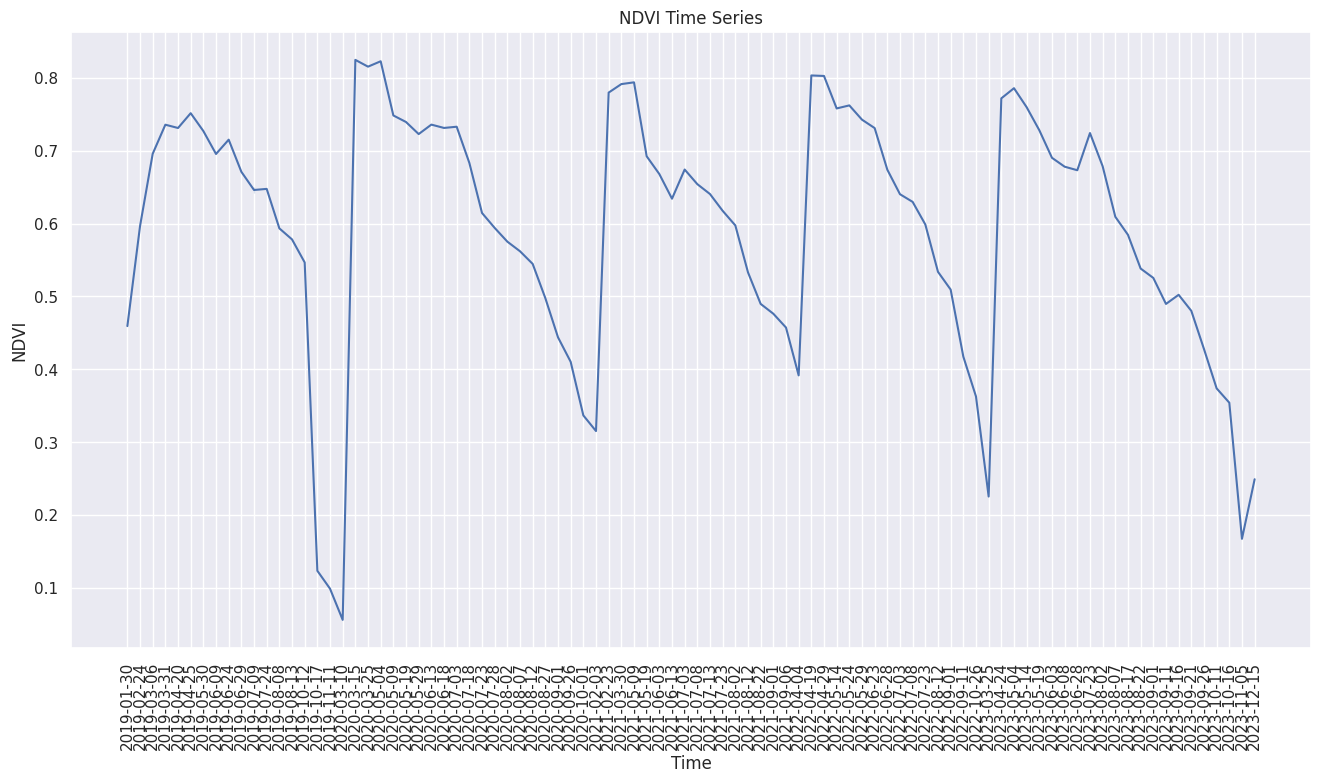

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
sns.set_theme(style="darkgrid")
sns.lineplot(x=lote_0.index, y='NDVI', data=lote_0)
plt.title('NDVI Time Series')
plt.xlabel('Time')
plt.xticks(rotation=90)
plt.ylabel('NDVI')
plt.show()

## Thank you! See you in the next Chapter!